# Single-phase MC-PILCO baseline analysis
Notebook version of `analyze_single_phase.py`.

In [1]:
%matplotlib inline
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [2]:
import os as _os, sys as _sys
_ROOT = _os.path.dirname(_os.path.abspath(""))
_sys.path.insert(0, _ROOT)
_sys.path.insert(0, _os.path.dirname(_ROOT))

from mcpilco.pensim_wrapper import (STATE_NAMES, STATE_RANGES, PAA_BAND, VISC_MAX,
                                    WARMUP_H, FPAA_MIN, FPAA_MAX, T_SAMPLING)
from utils.recipe import Recipe
from utils.constants import STEP_IN_HOURS
from PenSimPy.pensimpy.data.constants import DISCHARGE, DISCHARGE_DEFAULT_PROFILE

In [3]:
SEEDS = [0]
RESULTS_DIR = _os.path.join(_ROOT, "experiments/results/single_phase/")
RECIPE_DIR = _os.path.join(_ROOT, "results/batch_recipe_generation")
NUM_EXPLORATIONS = 5
RECIPE_BATCH = 0

P_IDX = STATE_NAMES.index("P")
_DISCH = Recipe(DISCHARGE_DEFAULT_PROFILE, DISCHARGE)
REF_STYLE = dict(color="red", lw=2.2, ls="--", zorder=6)

In [4]:
def load_recipe_reference(batch=RECIPE_BATCH, recipe_dir=RECIPE_DIR):
    d = Path(recipe_dir)
    m = pd.read_csv(d / "per_batch_metrics.csv").set_index("batch")
    ref = {"batch": batch,
           "final_P": float(m.loc[batch, "final_penicillin_conc"]),
           "yield": float(m.loc[batch, "yield"])}
    col = f"batch_{batch}"
    for key, fname in [("P", "penicillin_concentration_timeseries.csv"),
                       ("PAA", "paa_concentration_timeseries.csv"),
                       ("Viscosity", "viscosity_timeseries.csv"),
                       ("Fpaa", "fpaa_setpoint_timeseries.csv")]:
        fp = d / fname
        if fp.exists():
            ts = pd.read_csv(fp).set_index("time_h")
            ref[key] = (ts.index.values, ts[col].values)
    return ref
print(RECIPE_DIR)
print(RECIPE_BATCH)

/Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/results/batch_recipe_generation
0


In [5]:
def _denorm(x, lo, hi):
    return lo + (x + 1.0) * (hi - lo) / 2.0


def final_P(state_norm):
    P = _denorm(state_norm[:, P_IDX], *STATE_RANGES["P"])
    return float(P[-1]), float(P.mean())

In [6]:
def yield_kg(mon):
    P, V, t = mon["P"], mon["Wt"], mon["t"]
    Fdis = np.array([_DISCH.get_value_at(float(tt)) for tt in t])
    net = (P[-1] * V[-1] - P[0] * V[0]) / 1000.0
    harvest = float((P * Fdis * STEP_IN_HOURS).sum()) / 1000.0
    return net + harvest

In [7]:
def _ep_color(i, n_ep, n_expl):
    if i < n_expl:
        return "0.72"
    span = max(1, n_ep - n_expl - 1)
    return cm.viridis((i - n_expl) / span)

In [8]:
def main(seeds=SEEDS, results_dir=RESULTS_DIR,
         num_explorations=NUM_EXPLORATIONS, recipe_batch=RECIPE_BATCH):
    fig, ax = plt.subplots(2, 3, figsize=(16, 9))

    ref = load_recipe_reference(batch=recipe_batch)
    ref_lbl = f"recipe (seed {ref['batch']})"

    for s in seeds:
        d = Path(results_dir) / f"seed{s}"
        print(d)
        log_p, mon_p = d / "log.pkl", d / "monitor.pkl"
        print(log_p)
        print(mon_p)
        if not log_p.exists():
            print("TURI BEDA")
            continue

        hist = pickle.load(open(log_p, "rb"))["state_samples_history"]
        finals = np.array([final_P(b)[0] for b in hist])
        ax[0, 0].plot(np.arange(len(finals)), finals, marker="o", label=f"seed {s}")

        if not mon_p.exists():
            continue
        monitors = pickle.load(open(mon_p, "rb"))
        n_ep = len(monitors)

        yields = []
        for i, m in enumerate(monitors):
            c = _ep_color(i, n_ep, num_explorations)
            lbl = f"ep{i} {'expl' if i < num_explorations else 'trial'}"
            ax[0, 1].plot(m["t"], m["PAA"], color=c, lw=1, alpha=.85, label=lbl)
            ax[0, 2].plot(m["t"], m["Viscosity"], color=c, lw=1, alpha=.85, label=lbl)
            ax[1, 0].plot(m["t"], m["Fpaa"], color=c, lw=1, alpha=.85, label=lbl)
            ax[1, 1].plot(m["t"], m["P"], color=c, lw=1, alpha=.85)
            yields.append(yield_kg(m))
        yields = np.array(yields)
        colors = [_ep_color(i, n_ep, num_explorations) for i in range(n_ep)]
        ax[1, 2].bar(np.arange(n_ep), yields, color=colors)

    ax[0, 0].axhline(ref["final_P"], label=ref_lbl, **REF_STYLE)
    ax[1, 2].axhline(ref["yield"], label=ref_lbl, **REF_STYLE)
    for axis, key in [(ax[0, 1], "PAA"), (ax[0, 2], "Viscosity"),
                      (ax[1, 0], "Fpaa"), (ax[1, 1], "P")]:
        if key in ref:
            t, y = ref[key]
            axis.plot(t, y, label=ref_lbl, **REF_STYLE)

    ax[0, 0].set_title("Final penicillin conc per episode")
    ax[0, 0].set_xlabel("episode (0..=exploration then trials)"); ax[0, 0].set_ylabel("P (g/L)")
    ax[0, 0].grid(alpha=.3); ax[0, 0].legend(fontsize=8)

    ax[0, 1].axhspan(*PAA_BAND, color="green", alpha=.12, label="allowed band")
    ax[0, 1].axvline(WARMUP_H, color="gray", ls=":", label="RL on (100 h)")
    ax[0, 1].set_title("PAA conc (all episodes)"); ax[0, 1].set_xlabel("time (h)")
    ax[0, 1].set_ylabel("PAA (mg/L)"); ax[0, 1].grid(alpha=.3); ax[0, 1].legend(fontsize=6, ncol=2)

    ax[0, 2].axhline(VISC_MAX, color="crimson", ls="--", label=f"limit {VISC_MAX:.0f} cP")
    ax[0, 2].axvline(WARMUP_H, color="gray", ls=":", label="RL on (100 h)")
    ax[0, 2].set_title("Viscosity (all episodes)"); ax[0, 2].set_xlabel("time (h)")
    ax[0, 2].set_ylabel("viscosity (cP)"); ax[0, 2].grid(alpha=.3); ax[0, 2].legend(fontsize=6, ncol=2)

    ax[1, 0].axvline(WARMUP_H, color="gray", ls=":", label="RL on (100 h)")
    ax[1, 0].axhspan(FPAA_MIN, FPAA_MAX, color="orange", alpha=.06, label=f"clamp [{FPAA_MIN:.0f},{FPAA_MAX:.0f}]")
    ax[1, 0].set_title("FPAA setpoint = ACTION (all episodes)"); ax[1, 0].set_xlabel("time (h)")
    ax[1, 0].set_ylabel("Fpaa (L/h)"); ax[1, 0].grid(alpha=.3); ax[1, 0].legend(fontsize=6, ncol=2)

    ax[1, 1].axvline(WARMUP_H, color="gray", ls=":", label="RL on (100 h)")
    ax[1, 1].set_title("Penicillin trajectories (all episodes)"); ax[1, 1].set_xlabel("time (h)")
    ax[1, 1].set_ylabel("P (g/L)"); ax[1, 1].grid(alpha=.3)
    ax[1, 1].plot([], [], color="0.72", label="exploration"); ax[1, 1].plot([], [], color=cm.viridis(0.9), label="trials")
    ax[1, 1].legend(fontsize=8)

    ax[1, 2].set_title("Penicillin yield per episode")
    ax[1, 2].set_xlabel("episode"); ax[1, 2].set_ylabel("yield (kg)"); ax[1, 2].grid(alpha=.3, axis="y")
    ax[1, 2].legend(fontsize=8)

    fig.suptitle("Single-phase MC-PILCO baseline: reward (P), action (PAA), constraints, yield")
    fig.tight_layout()
    plt.show()

/Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/experiments/results/single_phase/seed0
/Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/experiments/results/single_phase/seed0/log.pkl
/Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/experiments/results/single_phase/seed0/monitor.pkl


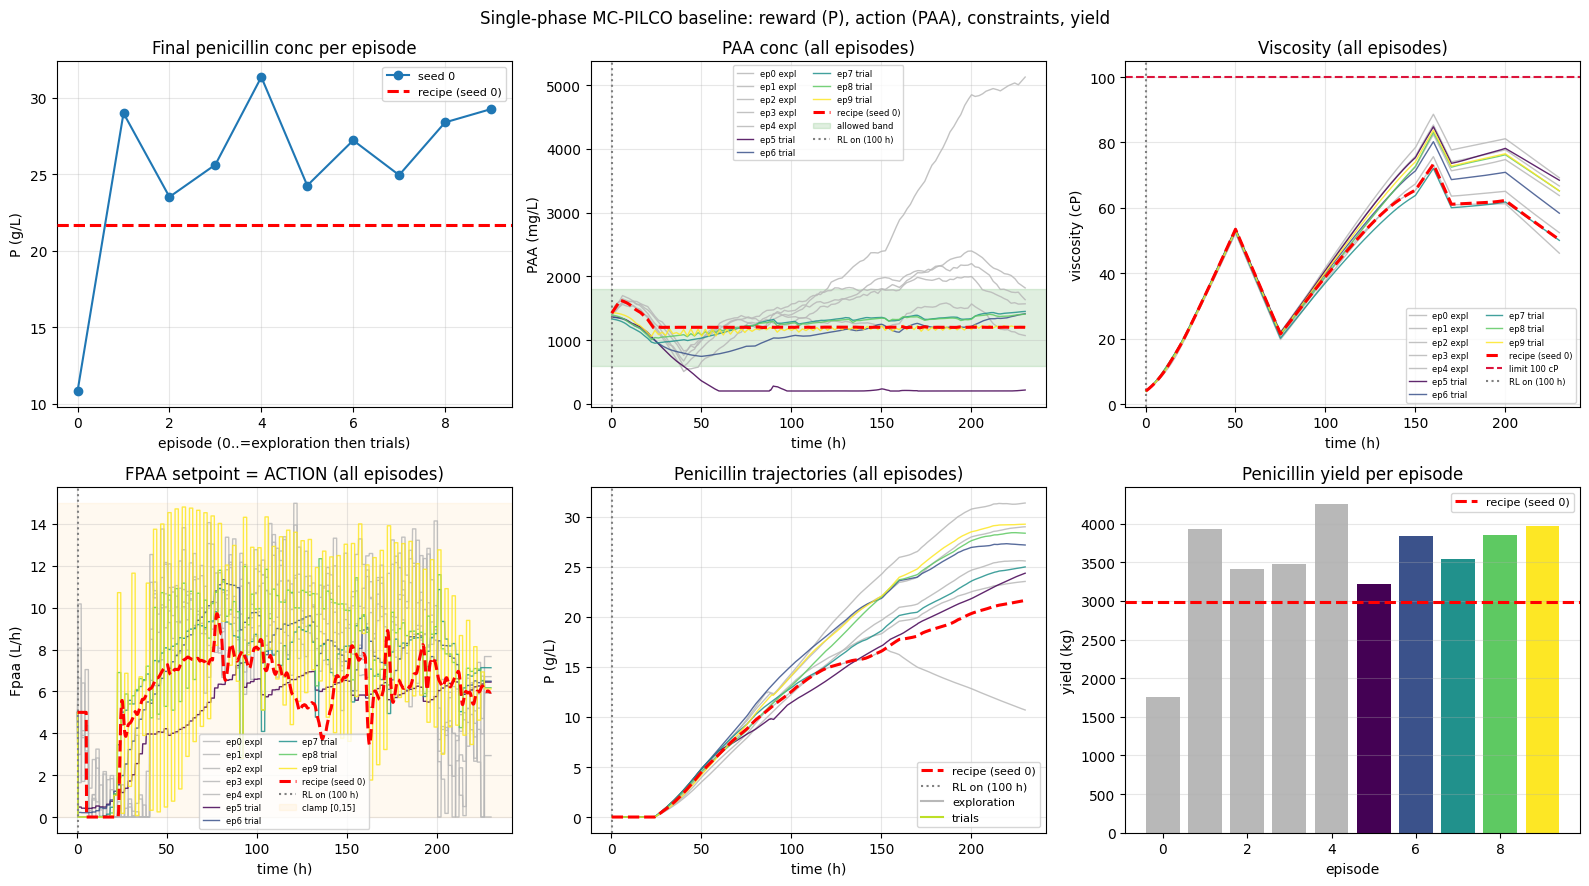

In [9]:
main()

## All observations
One time-series per element of the observation vector (`STATE_NAMES`), every episode overlaid (grey = exploration, viridis = trials). Trajectories come from `state_samples_history` (normalised) and are denormalised via `STATE_RANGES`; the recipe reference is overlaid where a matching series exists.

In [10]:
def plot_all_observations(seeds=SEEDS, results_dir=RESULTS_DIR,
                          num_explorations=NUM_EXPLORATIONS, recipe_batch=RECIPE_BATCH,
                          ncol=3):
    """One subplot per observation in STATE_NAMES, all episodes overlaid.

    States in `state_samples_history` are the normalised [-1, 1] observation
    vectors the agent sees; here they are denormalised back to physical units
    and plotted against decision time (WARMUP_H + k * T_SAMPLING)."""
    n_obs = len(STATE_NAMES)
    nrow = int(np.ceil(n_obs / ncol))
    ref = load_recipe_reference(batch=recipe_batch)
    ref_lbl = f"recipe (seed {ref['batch']})"

    for s in seeds:
        d = Path(results_dir) / f"seed{s}"
        log_p = d / "log.pkl"
        if not log_p.exists():
            print(f"missing {log_p}")
            continue
        hist = pickle.load(open(log_p, "rb"))["state_samples_history"]
        n_ep = len(hist)

        fig, ax = plt.subplots(nrow, ncol, figsize=(16, 3.6 * nrow), squeeze=False)
        axes = ax.ravel()

        for j, name in enumerate(STATE_NAMES):
            a = axes[j]
            lo, hi = STATE_RANGES[name]
            for i, b in enumerate(hist):
                y = _denorm(np.asarray(b)[:, j], lo, hi)
                t = WARMUP_H + np.arange(len(y)) * T_SAMPLING
                a.plot(t, y, color=_ep_color(i, n_ep, num_explorations),
                       lw=1, alpha=.85)
            if name in ref:                       # recipe reference series (P, PAA, ...)
                rt, ry = ref[name]
                a.plot(rt, ry, label=ref_lbl, **REF_STYLE)
            if name == "PAA":
                a.axhspan(*PAA_BAND, color="green", alpha=.12, label="allowed band")
            a.axvline(WARMUP_H, color="gray", ls=":", lw=.8)
            a.set_title(name)
            a.set_xlabel("time (h)")
            a.set_ylabel(f"{name}  (range {lo:g}..{hi:g})")
            a.grid(alpha=.3)
            if name in ref or name == "PAA":
                a.legend(fontsize=7)

        # exploration/trial colour key + a proxy so the legend is self-explanatory
        axes[0].plot([], [], color="0.72", label="exploration")
        axes[0].plot([], [], color=cm.viridis(0.9), label="trials")
        axes[0].legend(fontsize=7)

        for k in range(n_obs, len(axes)):         # blank any unused grid cells
            axes[k].axis("off")

        fig.suptitle(f"All observations per episode - seed {s}", y=1.002)
        fig.tight_layout()
        plt.show()


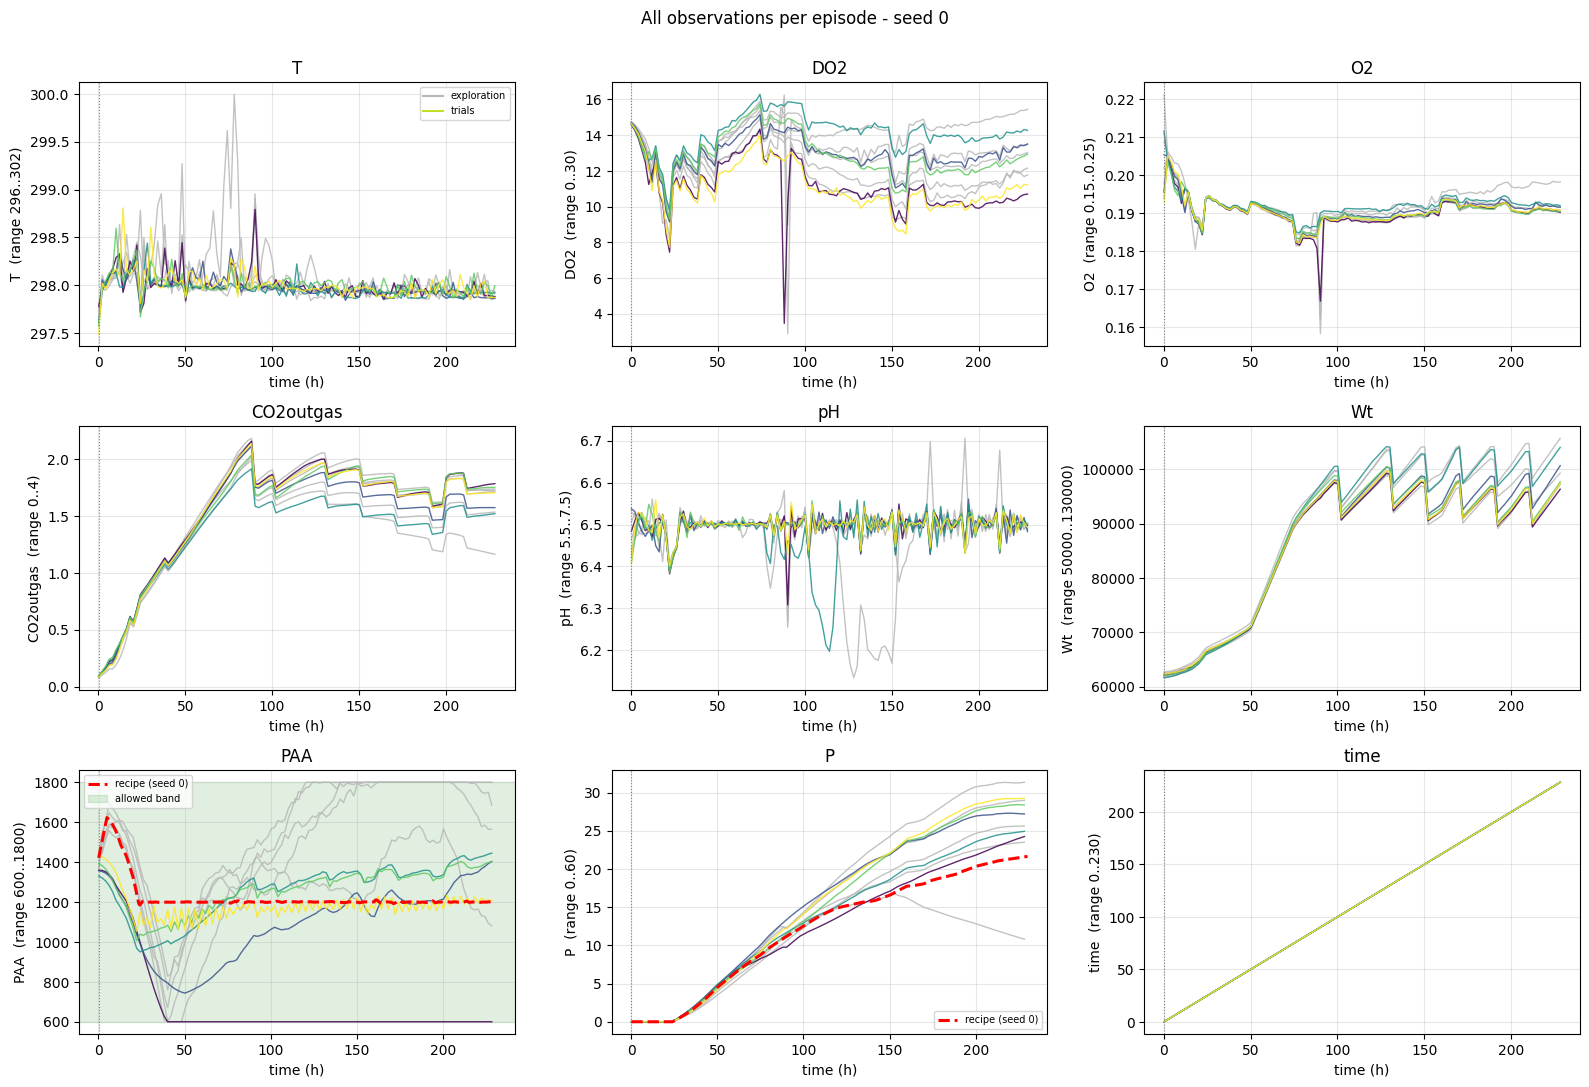

In [11]:
plot_all_observations()